In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data1.csv')
df

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,ctrlife,medtrnl,medtrnp,medtrnt,medtrref,fltdpr,fltlnl,fltsd,slprl,yrbrn
0,ESS9e03_3,9,3.3,26.01.2026,27,AT,0.581174,0.218111,0.302091,0.065890,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1975
1,ESS9e03_3,9,3.3,26.01.2026,137,AT,1.062772,0.413473,0.302091,0.124907,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1951
2,ESS9e03_3,9,3.3,26.01.2026,194,AT,1.376509,2.270293,0.302091,0.685836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1978
3,ESS9e03_3,9,3.3,26.01.2026,208,AT,0.993399,0.386483,0.302091,0.116753,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1955
4,ESS9e03_3,9,3.3,26.01.2026,220,AT,0.377353,1.032102,0.302091,0.311789,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159315,ESS11e04_2,11,4.2,02.07.2026,273742,UA,1.194824,1.194824,1.310703,1.566060,...,6.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,1973
159316,ESS11e04_2,11,4.2,02.07.2026,273743,UA,0.436757,0.436757,1.310703,0.572459,...,6.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,3.0,1959
159317,ESS11e04_2,11,4.2,02.07.2026,273747,UA,1.067750,1.067750,1.310703,1.399503,...,5.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,4.0,1954
159318,ESS11e04_2,11,4.2,02.07.2026,273838,UA,0.597412,0.597412,1.310703,0.783030,...,8.0,0.0,0.0,0.0,0.0,1.0,4.0,3.0,3.0,1947


# EDA

### Up to 2005 because the survey was conducted in 2023 so only adults 

In [2]:
# Select Millenials and GenZ
df = df[(df['yrbrn'] >= 1981) & (df['yrbrn'] < 2005)].copy()

#### Creating variables describing age and the generation, as they're not avaiable in the dataset

In [3]:
df['age'] = 2023 - df['yrbrn']
df['generation'] = np.where(df['yrbrn'] >= 1997, 'Gen Z', 'Millennial')

#### Selecting all variables that we want to examin

In [4]:
selected_cols = [
    'age',          
    'generation',   
    'netustm',      # Internet use in minutes
    'slprl',        # Restless sleep
    'ctrlife',      # Control over life
    'fltdpr',       # Felt depressed 
    'happy',        # Felt happy
    'health',       # General physical health
    'fltlnl',       # Felt lonely
    'fltsd',        # Felt sad
    'gndr',         # Gender
    'uemp3m',       # unemployment by more than 3 months
    'inprdsc',      # How many people with whom you can discuss intimate and personal matters
]

data_all = df[selected_cols]

#### The survey use codes to mark the missing values, we need to substitute them with nans

In [5]:
data_all['netustm'] = data_all['netustm'].replace([6666, 7777, 8888, 9999], np.nan)
data_all['happy'] = data_all['happy'].replace([77, 88, 99], np.nan)
data_all['ctrlife'] = data_all['ctrlife'].replace([77, 88, 99], np.nan)

for col in ['slprl', 'fltdpr', 'fltlnl', 'fltsd', 'health', 'gndr']:
    data_all[col] = data_all[col].replace([7, 8, 9], np.nan)

In [6]:
# fltdpr - feel depressed | variable of interest
print("Nans %", data_all['fltdpr'].isna().mean() * 100)

Nans % 67.83644353862812


### Since the survey data contains surveys done in different years, we need to select one that has our variable of interest populated 100%

In [7]:
data_all = data_all.dropna(subset=['fltdpr'])
print("Nans %", data_all['fltdpr'].isna().mean() * 100)

Nans % 0.0


In [8]:
data_all.head()

,age,generation,netustm,slprl,ctrlife,fltdpr,happy,health,fltlnl,fltsd,gndr,uemp3m,inprdsc
109205,21,Gen Z,570.0,3.0,8.0,2.0,9.0,2.0,3.0,2.0,2.0,2,4
109218,30,Millennial,NaN,1.0,6.0,2.0,5.0,3.0,1.0,2.0,2.0,2,4
109220,41,Millennial,360.0,2.0,8.0,1.0,10.0,1.0,1.0,2.0,1.0,2,6
109222,26,Gen Z,600.0,1.0,6.0,1.0,8.0,1.0,1.0,1.0,1.0,1,4
109223,42,Millennial,180.0,2.0,6.0,2.0,5.0,2.0,1.0,2.0,1.0,1,4


In [9]:
data_all.describe()

,age,netustm,slprl,ctrlife,fltdpr,happy,health,fltlnl,fltsd,gndr,uemp3m,inprdsc
count,15150.000000,14307.000000,15123.000000,15106.000000,15150.000000,15108.000000,15134.000000,15115.000000,15109.000000,15150.000000,15150.000000,15150.000000
mean,31.545017,301.511078,1.738412,7.403350,1.423564,7.505825,1.789679,1.395369,1.553180,1.530033,1.743168,3.333201
std,6.858320,201.395674,0.824308,1.926821,0.657499,1.760922,0.792382,0.660782,0.650376,0.499114,0.692732,5.712869
min,19.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,26.000000,150.000000,1.000000,6.000000,1.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,32.000000,240.000000,2.000000,8.000000,1.000000,8.000000,2.000000,1.000000,1.000000,2.000000,2.000000,3.000000
75%,38.000000,420.000000,2.000000,9.000000,2.000000,9.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000
max,42.000000,1440.000000,4.000000,10.000000,4.000000,10.000000,5.000000,4.000000,4.000000,2.000000,9.000000,99.000000


#### % of nan for all columns

In [10]:
for column in data_all.columns:
    print(f"{column} Nan % = {data_all[column].isna().mean() * 100}")

age Nan % = 0.0
generation Nan % = 0.0
netustm Nan % = 5.564356435643565
slprl Nan % = 0.17821782178217824
ctrlife Nan % = 0.29042904290429045
fltdpr Nan % = 0.0
happy Nan % = 0.2772277227722772
health Nan % = 0.1056105610561056
fltlnl Nan % = 0.23102310231023102
fltsd Nan % = 0.2706270627062706
gndr Nan % = 0.0
uemp3m Nan % = 0.0
inprdsc Nan % = 0.0


### I impute the missing internet usage by their generation median and drop every other missing values as they are around 0.3% 

In [11]:
data_all['netustm'] = data_all['netustm'].fillna(
    data_all.groupby('generation')['netustm'].transform('median')
)
data_all = data_all.dropna().reset_index(drop=True)
for column in data_all.columns:
    print(f"{column} Nan % = {data_all[column].isna().mean() * 100}")

age Nan % = 0.0
generation Nan % = 0.0
netustm Nan % = 0.0
slprl Nan % = 0.0
ctrlife Nan % = 0.0
fltdpr Nan % = 0.0
happy Nan % = 0.0
health Nan % = 0.0
fltlnl Nan % = 0.0
fltsd Nan % = 0.0
gndr Nan % = 0.0
uemp3m Nan % = 0.0
inprdsc Nan % = 0.0


#### Our data shows 73% of respondant are Millennial and 27% are Gen-z

In [12]:
generation_percentages = data_all['generation'].value_counts(normalize=True) * 100
round(generation_percentages, 1)

generation
Millennial    72.6
Gen Z         27.4
Name: proportion, dtype: float64

#### 53% of respondands are woman and 47% are man 

In [13]:
gender_percentages = data_all['gndr'].value_counts(normalize=True) * 100
round(gender_percentages, 1)

gndr
2.0    53.0
1.0    47.0
Name: proportion, dtype: float64

### mean internet usage per generations

In [14]:
mean_usage = data_all.groupby('generation')['netustm'].mean()
print("Average Daily Internet Usage (Minutes):")
print(mean_usage.round(2))

Average Daily Internet Usage (Minutes):
generation
Gen Z         325.91
Millennial    289.10
Name: netustm, dtype: float64


## indiviual usage of internet by generation

findfont: Failed to find font weight semibold, now using 700.


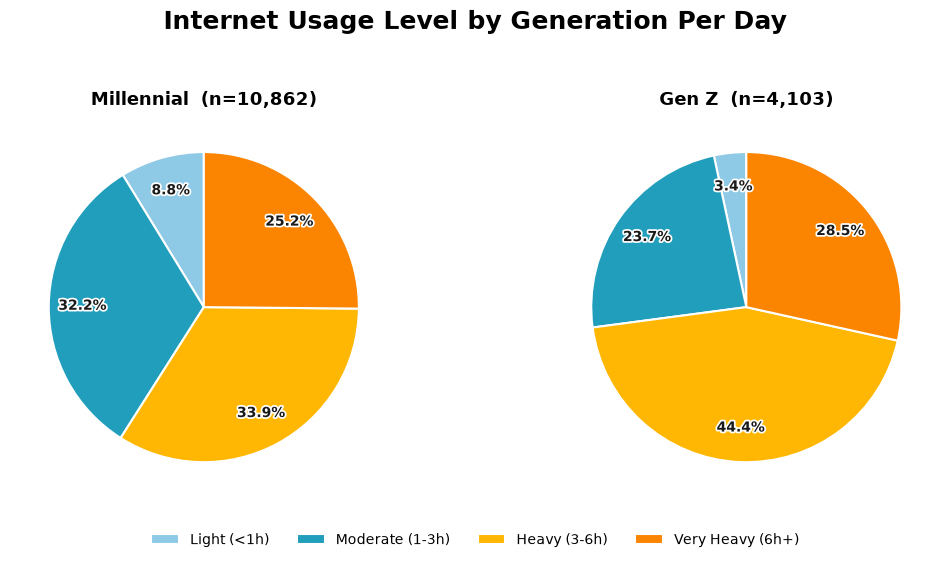

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

bins = [-1, 60, 180, 360, np.inf]
usage_labels = ['Light (<1h)', 'Moderate (1-3h)', 'Heavy (3-6h)', 'Very Heavy (6h+)']
data_all['usage_level'] = pd.cut(data_all['netustm'], bins=bins, labels=usage_labels)

gen_order = ['Millennial', 'Gen Z']
colors = ['#8ecae6', '#219ebc', '#ffb703', '#fb8500']

fig, axes = plt.subplots(1, len(gen_order), figsize=(11, 5.5))

for ax, gen in zip(axes, gen_order):
    counts = (
        data_all.loc[data_all['generation'] == gen, 'usage_level']
        .value_counts()
        .reindex(usage_labels)
        .fillna(0)
    )
    wedges, _, autotexts = ax.pie(
        counts,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        pctdistance=0.78,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops=dict(fontsize=10, fontweight='bold', color='#1a1a1a')
    )
    for t in autotexts:
        t.set_path_effects([pe.withStroke(linewidth=2.5, foreground='white')])
    ax.set_title(f'{gen}  (n={int(counts.sum()):,})', fontsize=13, fontweight='semibold', pad=6)

fig.suptitle('Internet Usage Level by Generation Per Day', fontsize=18, fontweight='bold', y=0.98)

fig.legend(
    wedges, usage_labels,
    loc='lower center', ncol=len(usage_labels),
    bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=10
)

plt.tight_layout(rect=[0, 0.06, 1, 0.90])
plt.show()

### mean of sadness and loneliness by generations scale (1-4) 1:least, 4:most


In [16]:
generation_emotional_means = data_all.groupby('generation')[['fltlnl', 'fltsd']].mean()

print("Mean Loneliness and Sadness by Generation:")
print(generation_emotional_means.round(2))

Mean Loneliness and Sadness by Generation:
            fltlnl  fltsd
generation               
Gen Z         1.43   1.57
Millennial    1.38   1.54


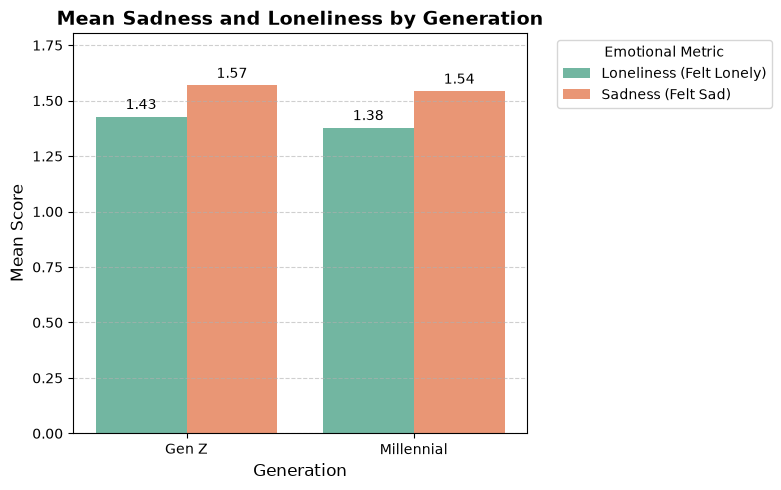

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_df = data_all.groupby('generation')[['fltlnl', 'fltsd']].mean().reset_index()

melted_df = mean_df.melt(id_vars='generation', 
                         value_vars=['fltlnl', 'fltsd'], 
                         var_name='Metric', 
                         value_name='Mean Score')

melted_df['Metric'] = melted_df['Metric'].replace({
    'fltlnl': 'Loneliness (Felt Lonely)', 
    'fltsd': 'Sadness (Felt Sad)'
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=melted_df, 
    x='generation', 
    y='Mean Score', 
    hue='Metric', 
    palette='Set2'
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='black',
                    xytext=(0, 3), textcoords='offset points')

plt.title('Mean Sadness and Loneliness by Generation', fontsize=14, fontweight='bold')
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Mean Score', fontsize=12)
plt.legend(title='Emotional Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, max(melted_df['Mean Score']) * 1.15)  
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Depression level by generations

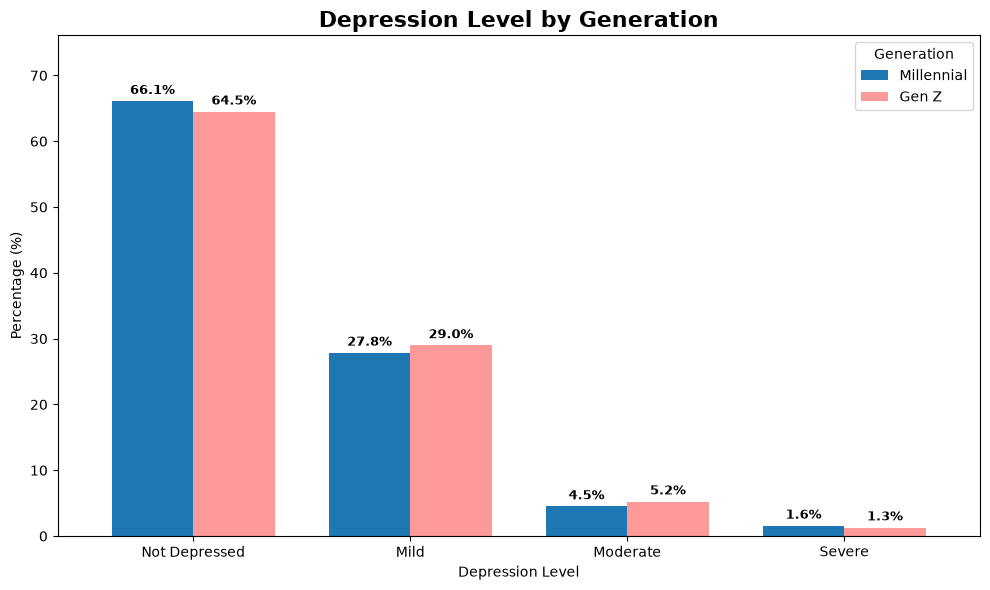

In [18]:
labels = {
    1: 'Not Depressed',
    2: 'Mild',
    3: 'Moderate',
    4: 'Severe'
}

data_all['depression_level'] = data_all['fltdpr'].map(labels)

counts = (
    data_all
    .groupby('generation', observed=True)['depression_level']
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=labels.values())
    .fillna(0) * 100
)

counts = counts.loc[['Millennial', 'Gen Z']]

# Plot
ax = counts.T.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#1f78b4', '#fb9a99'],
    width=0.75
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9,
        fontweight='bold'
    )

ax.set_xlabel('Depression Level')
ax.set_ylabel('Percentage (%)')
ax.set_title(
    'Depression Level by Generation',
    fontsize=16,
    fontweight='bold'
)

ax.set_xticklabels(labels.values(), rotation=0)
ax.legend(title='Generation')

ax.set_ylim(0, counts.max().max() + 10)

plt.tight_layout()
plt.show()


In [20]:
percentage_2_4 = (
    data_all[data_all['fltdpr'] >= 2]
    .groupby('generation')
    .size()
    / data_all.groupby('generation').size()
    * 100
)

relative_difference = (
    (percentage_2_4['Gen Z'] - percentage_2_4['Millennial'])
    / percentage_2_4['Millennial']
    * 100
)

print(f"Gen Z is relatively {round(relative_difference,2)}% more depressed than Millenials (Mild -> Severe)")

Gen Z is relatively 4.73% more depressed than Millenials (Mild -> Severe)


### Internet usage and depressive feelings by generation

Comparing the mean frequency of depressive feelings across daily internet usage groups for Millennials and Gen Z.

generation        Millennial  Gen Z
usage_level                        
Light (<1h)             1.40   1.41
Moderate (1-3h)         1.38   1.35
Heavy (3-6h)            1.45   1.43
Very Heavy (6h+)        1.42   1.51


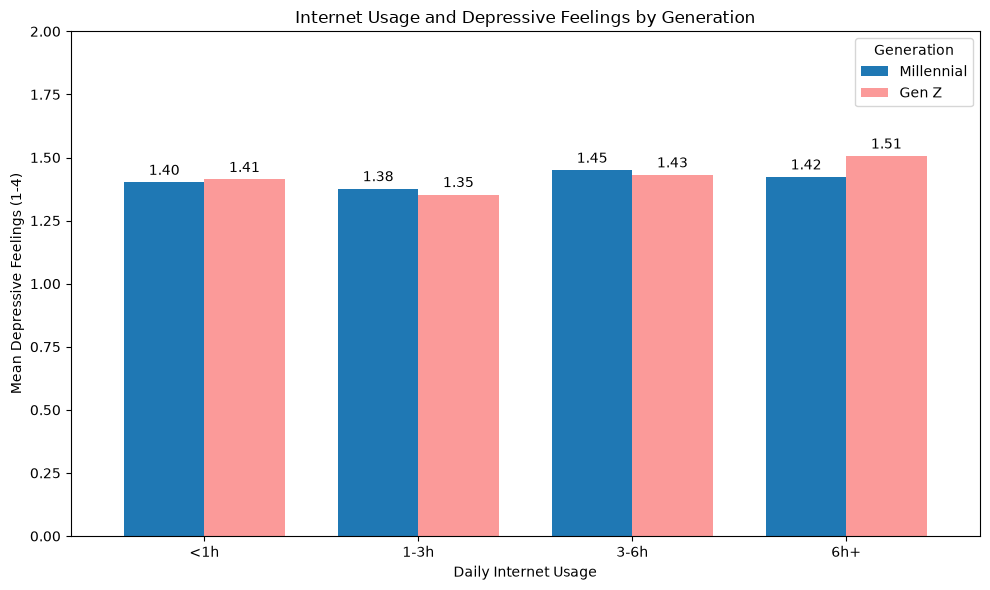

In [20]:

usage_order = [
    'Light (<1h)',
    'Moderate (1-3h)',
    'Heavy (3-6h)',
    'Very Heavy (6h+)'
]

mean_depression = (
    data_all
    .groupby(['usage_level', 'generation'], observed=True)['fltdpr']
    .mean()
    .unstack()
    .reindex(index=usage_order, columns=['Millennial', 'Gen Z'])
)

print(mean_depression.round(2))

ax = mean_depression.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#1f78b4', '#fb9a99'],
    width=0.75
)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3)

ax.set_title('Internet Usage and Depressive Feelings by Generation')
ax.set_xlabel('Daily Internet Usage')
ax.set_ylabel('Mean Depressive Feelings (1-4)')
ax.set_xticklabels(
    ['<1h', '1-3h', '3-6h', '6h+'],
    rotation=0
)
ax.set_ylim(0, 2)
ax.legend(title='Generation')

plt.tight_layout()
plt.show()

## Interpretation
The visualization shows small differences in depressive feelings across internet usage groups. Among Gen Z, respondents who spend more than six hours online daily report the highest average score (1.51). Among Millennials, the highest average score (1.45) is found in the 3–6 hour group. Overall, the results do not show a consistent increase in depressive feelings with internet usage across both generations. These findings indicate associations rather than causation.